# Training

## Loading real mawi trace dataset from csv

In [2]:
import pandas as pd
from pathlib import Path

benign_csv_path = Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/mawi20260000_first3_features.csv")

if not benign_csv_path.exists():
    raise FileNotFoundError(f"File not found: {benign_csv_path}")

benign_df = pd.read_csv(benign_csv_path)

print("Loaded:", benign_csv_path)
print("Rows:", benign_df.shape[0])
print("Columns:", benign_df.shape[1])

print("Column names:")
print(list(benign_df.columns))

display(benign_df.head())

Loaded: /home/ubuntu/DDoS_ML/preprocessing/features_out/mawi20260000_first3_features.csv
Rows: 2476811
Columns: 25
Column names:
['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'packet_count', 'duration', 'total_bytes', 'packets_per_second', 'bytes_per_second', 'packet_length_min', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'iat_min', 'iat_max', 'iat_mean', 'iat_std', 'tcp_syn_count', 'tcp_ack_count', 'tcp_fin_count', 'tcp_rst_count', 'tcp_psh_count', 'tcp_urg_count', 'label']


,src_ip,dst_ip,src_port,dst_port,protocol,packet_count,duration,total_bytes,packets_per_second,bytes_per_second,...,iat_max,iat_mean,iat_std,tcp_syn_count,tcp_ack_count,tcp_fin_count,tcp_rst_count,tcp_psh_count,tcp_urg_count,label
0,157.209.43.67,47.173.135.177,80,48978,TCP,3,0.000066,198,45425.675090,2.998095e+06,...,0.000035,0.000033,0.000003,0,3,0,0,0,0,Benign
1,146.195.151.206,150.189.32.126,443,32840,TCP,3,0.000031,198,96791.630769,6.388248e+06,...,0.000022,0.000015,0.000009,0,3,0,0,1,0,Benign
2,2001:4dfb:ea23:2c79:2d7c:7441:5e5c:1033,2404:643b:cb88:300e:7eff:8b8c:27f0:7f41,57765,443,UDP,3,0.000078,186,38479.853211,2.385751e+06,...,0.000076,0.000039,0.000052,0,0,0,0,0,0,Benign
3,71.81.13.209,150.189.109.193,443,58208,TCP,3,0.000010,198,299593.142857,1.977315e+07,...,0.000006,0.000005,0.000002,0,3,0,0,0,0,Benign
4,150.189.111.84,162.103.113.232,61885,443,UDP,3,0.000004,126,786432.000000,3.303014e+07,...,0.000003,0.000002,0.000001,0,0,0,0,0,0,Benign


## Loading DDoS data from multiple datasets

### Loading slow attacks from DDoD-AT-2022 and other attacks from CICDDoS2019

In [3]:
import pandas as pd
from pathlib import Path

# List attack CSV files here
attack_csv_paths = [
    Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/HTTP-slow-header_first3_features.csv"),
    Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/TCP-SYN-low_first3_features.csv"),
    Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/03-11/03-11/batch/combined_features_n3.csv"),
]

# Columns I want to remove before joining
columns_to_drop = [
    "pcap_file",
    "relative_path",
    "traffic_type",
    "label_source",
    "csv_match_time_diff",
    "flow_start_time",
    "flow_end_time"
]

# Labels to force for specific CSV files
label_overrides = {
    Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/HTTP-slow-header_first3_features.csv"): "HTTP-slow",
    Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/TCP-SYN-low_first3_features.csv"): "TCP-SYN-low",
}

### Dropping unwanted columns and over-writing labels

In [4]:
attack_dfs = []

for csv_path in attack_csv_paths:
    print("=" * 80)
    print("Loading:", csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(f"File not found: {csv_path}")

    temp_df = pd.read_csv(csv_path)

    print("Shape before dropping columns:", temp_df.shape)
    print("Columns:")
    print(list(temp_df.columns))

    existing_drop_cols = [col for col in columns_to_drop if col in temp_df.columns]

    if existing_drop_cols:
        temp_df = temp_df.drop(columns=existing_drop_cols)
        print("Dropped columns:", existing_drop_cols)
    else:
        print("No columns dropped.")

    if csv_path in label_overrides:
        temp_df["label"] = label_overrides[csv_path]
        print("Overwrote label with:", label_overrides[csv_path])
    else:
        print("Kept original label column.")

    print("Shape after dropping columns:", temp_df.shape)

    attack_dfs.append({
        "path": csv_path,
        "df": temp_df
    })

Loading: /home/ubuntu/DDoS_ML/preprocessing/features_out/HTTP-slow-header_first3_features.csv
Shape before dropping columns: (18116, 28)
Columns:
['pcap_file', 'relative_path', 'traffic_type', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'packet_count', 'duration', 'total_bytes', 'packets_per_second', 'bytes_per_second', 'packet_length_min', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'iat_min', 'iat_max', 'iat_mean', 'iat_std', 'tcp_syn_count', 'tcp_ack_count', 'tcp_fin_count', 'tcp_rst_count', 'tcp_psh_count', 'tcp_urg_count', 'label']
Dropped columns: ['pcap_file', 'relative_path', 'traffic_type']
Overwrote label with: HTTP-slow
Shape after dropping columns: (18116, 25)
Loading: /home/ubuntu/DDoS_ML/preprocessing/features_out/TCP-SYN-low_first3_features.csv


Shape before dropping columns: (64016, 28)
Columns:
['pcap_file', 'relative_path', 'traffic_type', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'packet_count', 'duration', 'total_bytes', 'packets_per_second', 'bytes_per_second', 'packet_length_min', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'iat_min', 'iat_max', 'iat_mean', 'iat_std', 'tcp_syn_count', 'tcp_ack_count', 'tcp_fin_count', 'tcp_rst_count', 'tcp_psh_count', 'tcp_urg_count', 'label']
Dropped columns: ['pcap_file', 'relative_path', 'traffic_type']
Overwrote label with: TCP-SYN-low
Shape after dropping columns: (64016, 25)
Loading: /home/ubuntu/DDoS_ML/preprocessing/features_out/03-11/03-11/batch/combined_features_n3.csv
Shape before dropping columns: (2769585, 29)
Columns:
['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'flow_start_time', 'flow_end_time', 'packet_count', 'duration', 'total_bytes', 'packets_per_second', 'bytes_per_second', 'packet_length_min', 'packet_length_max', 'pack

### Checking for exact match for columns in attack and benign data

In [5]:
# =========================
# Check attack dataframe columns
# =========================

reference_attack_path = attack_dfs[0]["path"]
reference_attack_cols = list(attack_dfs[0]["df"].columns)

attack_columns_match = True

for item in attack_dfs:
    current_path = item["path"]
    current_cols = list(item["df"].columns)

    print("=" * 80)
    print("Checking:", current_path)

    if current_cols == reference_attack_cols:
        print("Columns match exactly and are in the same order.")
    else:
        attack_columns_match = False
        print("Columns DO NOT match exactly.")

        missing_from_current = [col for col in reference_attack_cols if col not in current_cols]
        extra_in_current = [col for col in current_cols if col not in reference_attack_cols]

        print("Missing columns compared to reference:")
        print(missing_from_current)

        print("Extra columns compared to reference:")
        print(extra_in_current)

        print("Column order / position differences:")
        max_len = max(len(reference_attack_cols), len(current_cols))

        for i in range(max_len):
            ref_col = reference_attack_cols[i] if i < len(reference_attack_cols) else None
            cur_col = current_cols[i] if i < len(current_cols) else None

            if ref_col != cur_col:
                print(f"Position {i}: reference={ref_col}, current={cur_col}")

Checking: /home/ubuntu/DDoS_ML/preprocessing/features_out/HTTP-slow-header_first3_features.csv
Columns match exactly and are in the same order.
Checking: /home/ubuntu/DDoS_ML/preprocessing/features_out/TCP-SYN-low_first3_features.csv
Columns match exactly and are in the same order.
Checking: /home/ubuntu/DDoS_ML/preprocessing/features_out/03-11/03-11/batch/combined_features_n3.csv
Columns match exactly and are in the same order.


In [6]:
# =========================
# Check attack columns vs benign columns
# =========================

benign_cols = list(benign_df.columns)
attack_cols = reference_attack_cols

print("=" * 80)
print("Checking attack columns against benign_df columns")

if attack_cols == benign_cols:
    print("Attack and benign columns match exactly and are in the same order.")
else:
    print("Attack and benign columns DO NOT match exactly.")

    missing_from_attack = [col for col in benign_cols if col not in attack_cols]
    extra_in_attack = [col for col in attack_cols if col not in benign_cols]

    print("Columns in benign_df but missing from attack:")
    print(missing_from_attack)

    print("Columns in attack but missing from benign_df:")
    print(extra_in_attack)

    print("Column order / position differences:")
    max_len = max(len(benign_cols), len(attack_cols))

    for i in range(max_len):
        benign_col = benign_cols[i] if i < len(benign_cols) else None
        attack_col = attack_cols[i] if i < len(attack_cols) else None

        if benign_col != attack_col:
            print(f"Position {i}: benign={benign_col}, attack={attack_col}")

    raise ValueError("Attack and benign columns do not match exactly. Fix this before training.")

Checking attack columns against benign_df columns
Attack and benign columns match exactly and are in the same order.


### Joining all dataframes in attack_df

In [7]:
attack_df = pd.concat(
    [item["df"] for item in attack_dfs],
    ignore_index=True
)

print("Final attack_df shape:", attack_df.shape)
print("Labels in final attack_df:")
print(attack_df["label"].value_counts())

display(attack_df.head())

Final attack_df shape: (2851717, 25)
Labels in final attack_df:
label
UDP            1941505
Syn             754745
TCP-SYN-low      64016
BENIGN           23744
unknown          20747
MSSQL            19417
HTTP-slow        18116
NetBIOS           6628
LDAP              2286
Portmap            363
UDPLag             150
Name: count, dtype: int64


,src_ip,dst_ip,src_port,dst_port,protocol,packet_count,duration,total_bytes,packets_per_second,bytes_per_second,...,iat_max,iat_mean,iat_std,tcp_syn_count,tcp_ack_count,tcp_fin_count,tcp_rst_count,tcp_psh_count,tcp_urg_count,label
0,10.10.0.10,192.168.10.11,36400,80,TCP,3,0.001158,218,2590.675726,188255.769405,...,0.001157,0.000579,0.000817,2,1,0,0,0,0,HTTP-slow
1,10.10.0.10,192.168.10.11,36398,80,TCP,3,0.001153,218,2601.925558,189073.257237,...,0.001153,0.000576,0.000815,2,1,0,0,0,0,HTTP-slow
2,192.168.10.11,10.10.0.10,80,36398,TCP,3,0.005042,218,594.993002,43236.158124,...,0.005042,0.002521,0.003565,2,3,0,0,0,0,HTTP-slow
3,192.168.10.11,10.10.0.10,80,36400,TCP,3,0.005042,218,595.021138,43238.202677,...,0.005042,0.002521,0.003565,2,3,0,0,0,0,HTTP-slow
4,10.10.0.10,192.168.10.11,36402,80,TCP,3,0.000799,218,3753.852029,272779.914081,...,0.000799,0.000400,0.000565,2,1,0,0,0,0,HTTP-slow


### Dropping sample based on labels from the attach data

In [8]:
# =========================
# Drop attack_df rows by label
# =========================

label_column = "label"

if label_column not in attack_df.columns:
    raise KeyError(f"Column '{label_column}' not found. Available columns are: {list(attack_df.columns)}")

print("Labels before dropping:")
print(attack_df[label_column].value_counts())

labels_to_drop = [
    "BENIGN",
    "unknown",
    # add labels you want to remove here
]

attack_df = attack_df[~attack_df[label_column].isin(labels_to_drop)].copy()

print("\nLabels after dropping:")
print(attack_df[label_column].value_counts())

print("\nNew attack_df shape:", attack_df.shape)

Labels before dropping:


label
UDP            1941505
Syn             754745
TCP-SYN-low      64016
BENIGN           23744
unknown          20747
MSSQL            19417
HTTP-slow        18116
NetBIOS           6628
LDAP              2286
Portmap            363
UDPLag             150
Name: count, dtype: int64

Labels after dropping:
label
UDP            1941505
Syn             754745
TCP-SYN-low      64016
MSSQL            19417
HTTP-slow        18116
NetBIOS           6628
LDAP              2286
Portmap            363
UDPLag             150
Name: count, dtype: int64

New attack_df shape: (2807226, 25)


### Creating ddos_df for binary classification

In [9]:
# =========================
# Create binary DDoS dataframe
# =========================

ddos_df_binary = attack_df.copy()
ddos_df_binary["label"] = "ddos"

print("ddos_df_binary shape:", ddos_df_binary.shape)
print("Labels in ddos_df_binary:")
print(ddos_df_binary["label"].value_counts())
display(ddos_df_binary.head())

ddos_df_binary shape: (2807226, 25)
Labels in ddos_df_binary:
label
ddos    2807226
Name: count, dtype: int64


,src_ip,dst_ip,src_port,dst_port,protocol,packet_count,duration,total_bytes,packets_per_second,bytes_per_second,...,iat_max,iat_mean,iat_std,tcp_syn_count,tcp_ack_count,tcp_fin_count,tcp_rst_count,tcp_psh_count,tcp_urg_count,label
0,10.10.0.10,192.168.10.11,36400,80,TCP,3,0.001158,218,2590.675726,188255.769405,...,0.001157,0.000579,0.000817,2,1,0,0,0,0,ddos
1,10.10.0.10,192.168.10.11,36398,80,TCP,3,0.001153,218,2601.925558,189073.257237,...,0.001153,0.000576,0.000815,2,1,0,0,0,0,ddos
2,192.168.10.11,10.10.0.10,80,36398,TCP,3,0.005042,218,594.993002,43236.158124,...,0.005042,0.002521,0.003565,2,3,0,0,0,0,ddos
3,192.168.10.11,10.10.0.10,80,36400,TCP,3,0.005042,218,595.021138,43238.202677,...,0.005042,0.002521,0.003565,2,3,0,0,0,0,ddos
4,10.10.0.10,192.168.10.11,36402,80,TCP,3,0.000799,218,3753.852029,272779.914081,...,0.000799,0.000400,0.000565,2,1,0,0,0,0,ddos


### Creating ddos_df for multiclass classification

In [10]:
# =========================
# Map raw attack labels → 7 canonical classes
# =========================

label_map = {
    "UDP":         "UDP",
    "UDPLag":      "UDP",
    "Syn":         "SYN",
    "TCP-SYN-low": "slow-attacks",
    "HTTP-slow":   "slow-attacks",
    "MSSQL":       "MSSQL",
    "NetBIOS":     "NETBIOS",
    "LDAP":        "LDAP",
    "Portmap":     "Portmap",
}

ddos_df_multi = attack_df.copy()
ddos_df_multi["label"] = ddos_df_multi["label"].map(label_map)

unmapped_count = ddos_df_multi["label"].isna().sum()
if unmapped_count > 0:
    print(f"WARNING: {unmapped_count} rows have unmapped labels and will be dropped.")
    print("Unmapped original labels:")
    print(attack_df.loc[ddos_df_multi["label"].isna(), "label"].value_counts())
    ddos_df_multi = ddos_df_multi.dropna(subset=["label"]).copy()

print("ddos_df_multi shape:", ddos_df_multi.shape)
print("\nLabels in ddos_df_multi:")
print(ddos_df_multi["label"].value_counts())
display(ddos_df_multi.head())

ddos_df_multi shape: (2807226, 25)

Labels in ddos_df_multi:
label
UDP             1941655
SYN              754745
slow-attacks      82132
MSSQL             19417
NETBIOS            6628
LDAP               2286
Portmap             363
Name: count, dtype: int64


,src_ip,dst_ip,src_port,dst_port,protocol,packet_count,duration,total_bytes,packets_per_second,bytes_per_second,...,iat_max,iat_mean,iat_std,tcp_syn_count,tcp_ack_count,tcp_fin_count,tcp_rst_count,tcp_psh_count,tcp_urg_count,label
0,10.10.0.10,192.168.10.11,36400,80,TCP,3,0.001158,218,2590.675726,188255.769405,...,0.001157,0.000579,0.000817,2,1,0,0,0,0,slow-attacks
1,10.10.0.10,192.168.10.11,36398,80,TCP,3,0.001153,218,2601.925558,189073.257237,...,0.001153,0.000576,0.000815,2,1,0,0,0,0,slow-attacks
2,192.168.10.11,10.10.0.10,80,36398,TCP,3,0.005042,218,594.993002,43236.158124,...,0.005042,0.002521,0.003565,2,3,0,0,0,0,slow-attacks
3,192.168.10.11,10.10.0.10,80,36400,TCP,3,0.005042,218,595.021138,43238.202677,...,0.005042,0.002521,0.003565,2,3,0,0,0,0,slow-attacks
4,10.10.0.10,192.168.10.11,36402,80,TCP,3,0.000799,218,3753.852029,272779.914081,...,0.000799,0.000400,0.000565,2,1,0,0,0,0,slow-attacks


## Data preprocessing

In [11]:
# =========================
# Prepare benign labels
# =========================

benign_df = benign_df.copy()
benign_df["label"] = "benign"

print("benign_df shape:", benign_df.shape)
print(benign_df["label"].value_counts())

benign_df shape: (2476811, 25)
label
benign    2476811
Name: count, dtype: int64


In [12]:
# =========================
# Combine benign and binary DDoS data
# =========================

model_df = pd.concat([benign_df, ddos_df_binary], ignore_index=True)

print("model_df shape:", model_df.shape)
print("Labels:")
print(model_df["label"].value_counts())
display(model_df.head())

model_df shape: (5284037, 25)
Labels:
label
ddos      2807226
benign    2476811
Name: count, dtype: int64


,src_ip,dst_ip,src_port,dst_port,protocol,packet_count,duration,total_bytes,packets_per_second,bytes_per_second,...,iat_max,iat_mean,iat_std,tcp_syn_count,tcp_ack_count,tcp_fin_count,tcp_rst_count,tcp_psh_count,tcp_urg_count,label
0,157.209.43.67,47.173.135.177,80,48978,TCP,3,0.000066,198,45425.675090,2.998095e+06,...,0.000035,0.000033,0.000003,0,3,0,0,0,0,benign
1,146.195.151.206,150.189.32.126,443,32840,TCP,3,0.000031,198,96791.630769,6.388248e+06,...,0.000022,0.000015,0.000009,0,3,0,0,1,0,benign
2,2001:4dfb:ea23:2c79:2d7c:7441:5e5c:1033,2404:643b:cb88:300e:7eff:8b8c:27f0:7f41,57765,443,UDP,3,0.000078,186,38479.853211,2.385751e+06,...,0.000076,0.000039,0.000052,0,0,0,0,0,0,benign
3,71.81.13.209,150.189.109.193,443,58208,TCP,3,0.000010,198,299593.142857,1.977315e+07,...,0.000006,0.000005,0.000002,0,3,0,0,0,0,benign
4,150.189.111.84,162.103.113.232,61885,443,UDP,3,0.000004,126,786432.000000,3.303014e+07,...,0.000003,0.000002,0.000001,0,0,0,0,0,0,benign


In [13]:
# =========================
# Separate X and y
# =========================

target_column = "label"

X = model_df.drop(columns=[target_column])
y = model_df[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Feature columns:")
print(list(X.columns))

X shape: (5284037, 24)
y shape: (5284037,)
Feature columns:
['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'packet_count', 'duration', 'total_bytes', 'packets_per_second', 'bytes_per_second', 'packet_length_min', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'iat_min', 'iat_max', 'iat_mean', 'iat_std', 'tcp_syn_count', 'tcp_ack_count', 'tcp_fin_count', 'tcp_rst_count', 'tcp_psh_count', 'tcp_urg_count']


In [14]:
# =========================
# Check feature data types
# =========================

print(X.dtypes)

src_ip                 object
dst_ip                 object
src_port                int64
dst_port                int64
protocol               object
packet_count            int64
duration              float64
total_bytes             int64
packets_per_second    float64
bytes_per_second      float64
packet_length_min       int64
packet_length_max       int64
packet_length_mean    float64
packet_length_std     float64
iat_min               float64
iat_max               float64
iat_mean              float64
iat_std               float64
tcp_syn_count           int64
tcp_ack_count           int64
tcp_fin_count           int64
tcp_rst_count           int64
tcp_psh_count           int64
tcp_urg_count           int64
dtype: object


In [15]:
# List non-numeric feature columns
non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Non-numeric columns:")
print(non_numeric_cols)

Non-numeric columns:
['src_ip', 'dst_ip', 'protocol']


In [16]:
columns_to_remove_from_features = [
    "src_ip",
    "dst_ip",
    "src_port",
    "dst_port",
    "protocol",
]

X = X.drop(columns=[col for col in columns_to_remove_from_features if col in X.columns])

print("X shape after removing non-feature columns:", X.shape)
print("Remaining feature columns:")
print(list(X.columns))

X shape after removing non-feature columns: (5284037, 19)
Remaining feature columns:
['packet_count', 'duration', 'total_bytes', 'packets_per_second', 'bytes_per_second', 'packet_length_min', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'iat_min', 'iat_max', 'iat_mean', 'iat_std', 'tcp_syn_count', 'tcp_ack_count', 'tcp_fin_count', 'tcp_rst_count', 'tcp_psh_count', 'tcp_urg_count']


In [17]:
# =========================
# Keep only numeric features
# =========================

non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Non-numeric columns that will be removed:")
print(non_numeric_cols)

X_numeric = X.drop(columns=non_numeric_cols)

print("Original X shape:", X.shape)
print("Numeric X shape:", X_numeric.shape)

Non-numeric columns that will be removed:
[]
Original X shape: (5284037, 19)
Numeric X shape: (5284037, 19)


In [18]:
# =========================
# Check missing and infinite values
# =========================

import numpy as np

print("Total missing values:")
print(X_numeric.isna().sum().sum())

print("Total infinite values:")
print(np.isinf(X_numeric).sum().sum())

Total missing values:
0
Total infinite values:
0


In [19]:
# =========================
# Check labels
# =========================

print("Labels:")
print(y.value_counts())

Labels:
label
ddos      2807226
benign    2476811
Name: count, dtype: int64


In [20]:
# =========================
# Train/test split
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

X_train shape: (4227229, 19)
X_test shape: (1056808, 19)

Training labels:
label
ddos      2245780
benign    1981449
Name: count, dtype: int64

Testing labels:
label
ddos      561446
benign    495362
Name: count, dtype: int64


### Multiclass data preparation

In [21]:
# =========================
# Combine benign + multiclass attack data and split
# =========================

import numpy as np
from sklearn.model_selection import train_test_split

print("=== Multiclass ===")

model_df_mc = pd.concat([benign_df, ddos_df_multi], ignore_index=True)
print("model_df_mc shape:", model_df_mc.shape)
print("Labels:\n", model_df_mc["label"].value_counts())

X_mc = model_df_mc.drop(columns=["label"])
y_mc = model_df_mc["label"]

_id_cols = ["src_ip", "dst_ip", "src_port", "dst_port", "protocol"]
X_mc = X_mc.drop(columns=[c for c in _id_cols if c in X_mc.columns])
X_mc = X_mc.select_dtypes(include=["number"])

print(f"\nMissing values: {X_mc.isna().sum().sum()}")
print(f"Infinite values: {np.isinf(X_mc).sum().sum()}")

X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc
)

print("\nX_train_mc shape:", X_train_mc.shape)
print("X_test_mc shape:", X_test_mc.shape)
print("\nTraining labels:\n", y_train_mc.value_counts())
print("\nTesting labels:\n", y_test_mc.value_counts())

=== Multiclass ===


model_df_mc shape: (5284037, 25)
Labels:
 label
benign          2476811
UDP             1941655
SYN              754745
slow-attacks      82132
MSSQL             19417
NETBIOS            6628
LDAP               2286
Portmap             363
Name: count, dtype: int64

Missing values: 0
Infinite values: 0

X_train_mc shape: (4227229, 19)
X_test_mc shape: (1056808, 19)

Training labels:
 label
benign          1981448
UDP             1553324
SYN              603796
slow-attacks      65706
MSSQL             15534
NETBIOS            5302
LDAP               1829
Portmap             290
Name: count, dtype: int64

Testing labels:
 label
benign          495363
UDP             388331
SYN             150949
slow-attacks     16426
MSSQL             3883
NETBIOS           1326
LDAP               457
Portmap             73
Name: count, dtype: int64


## Select Features

In [22]:
# =========================
# Feature selection
# Comment out any features you want to exclude from training
# =========================

selected_features = [
    # "packet_count",
    # "duration",
    # "total_bytes",
    # "packets_per_second",
    # "bytes_per_second",
    # "packet_length_min",
    "packet_length_max",
    # "packet_length_mean",
    # "packet_length_std",
    "iat_min",
    # "iat_max",
    # "iat_mean",
    # "iat_std",
    # "tcp_syn_count",
    # "tcp_ack_count",
    # "tcp_fin_count",
    # "tcp_rst_count",
    # "tcp_psh_count",
    # "tcp_urg_count",
]

print(f"Selected {len(selected_features)} features:")
print(selected_features)

Selected 2 features:
['packet_length_max', 'iat_min']


In [23]:
# Apply feature selection to binary and multiclass datasets
X_train    = X_train[selected_features]
X_test     = X_test[selected_features]
X_train_mc = X_train_mc[selected_features]
X_test_mc  = X_test_mc[selected_features]

print("Binary     — X_train:", X_train.shape,    "| X_test:", X_test.shape)
print("Multiclass — X_train:", X_train_mc.shape, "| X_test:", X_test_mc.shape)

Binary     — X_train: (4227229, 2) | X_test: (1056808, 2)
Multiclass — X_train: (4227229, 2) | X_test: (1056808, 2)


## 2D Scatter Plot Visualization

/tmp/ipykernel_2071124/2636883300.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = cm.get_cmap("tab10", len(mc_classes))


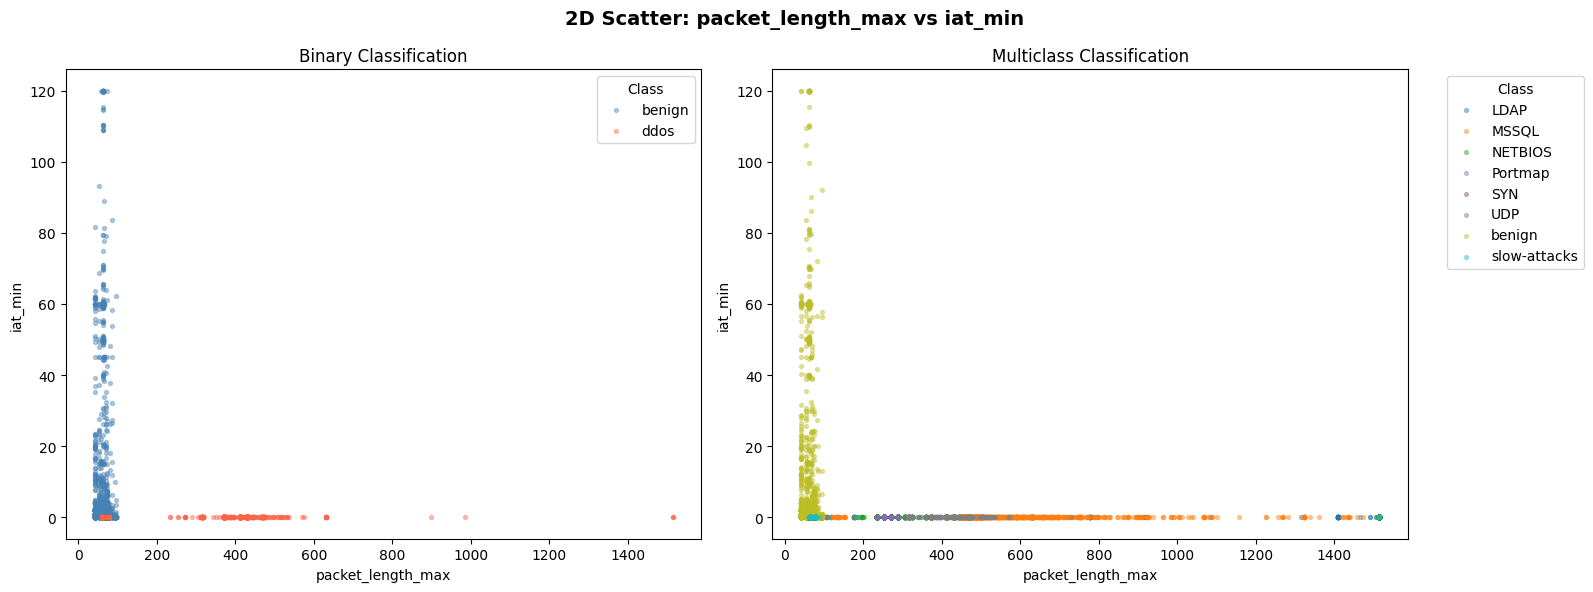

In [24]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

if len(selected_features) < 2:
    raise ValueError("Need at least 2 selected features for a 2D scatter plot.")

feat_x, feat_y = selected_features[0], selected_features[1]
sample_n = 5000  # points per class to keep the plot fast

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Binary scatter ---
ax = axes[0]
df_vis_bin = pd.concat([X_train, X_test])
y_vis_bin  = pd.concat([y_train, y_test])

colors_bin = {"benign": "steelblue", "ddos": "tomato"}
for cls in sorted(y_vis_bin.unique()):
    mask = y_vis_bin == cls
    idx  = df_vis_bin[mask].sample(min(sample_n, int(mask.sum())), random_state=0).index
    ax.scatter(df_vis_bin.loc[idx, feat_x], df_vis_bin.loc[idx, feat_y],
               label=cls, alpha=0.4, s=8, color=colors_bin.get(cls, "gray"))
ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_title("Binary Classification")
ax.legend(title="Class")

# --- Multiclass scatter ---
ax = axes[1]
df_vis_mc = pd.concat([X_train_mc, X_test_mc])
y_vis_mc  = pd.concat([y_train_mc, y_test_mc])

mc_classes = sorted(y_vis_mc.unique())
palette = cm.get_cmap("tab10", len(mc_classes))
for i, cls in enumerate(mc_classes):
    mask = y_vis_mc == cls
    idx  = df_vis_mc[mask].sample(min(sample_n, int(mask.sum())), random_state=0).index
    ax.scatter(df_vis_mc.loc[idx, feat_x], df_vis_mc.loc[idx, feat_y],
               label=cls, alpha=0.4, s=8, color=palette(i))
ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_title("Multiclass Classification")
ax.legend(title="Class", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.suptitle(f"2D Scatter: {feat_x} vs {feat_y}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Model Training

In [25]:
# =========================
# Model evaluation helper
# =========================

import sys
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, X_train, X_test, y_train, y_test, name="Model"):
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - t0

    model_size_kb = sys.getsizeof(model) / 1024
    print(f"Train time: {train_time:.1f}s | Pred time: {pred_time:.3f}s | Model size: {model_size_kb:.1f} KB")

    labels = sorted(model.classes_)
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    print(f"\nConfusion matrix:\n{cm}")
    print(f"\nClassification report:")
    print(classification_report(y_test, y_pred, labels=labels))

    fig, ax = plt.subplots(figsize=(max(6, len(labels)), max(5, len(labels) - 1)))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels, yticklabels=labels, ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{name} — Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return model, y_pred

### K-Nearest Neighbors (KNN) Binary

Classifies each test sample by majority vote among its `k` nearest training neighbors (Euclidean distance). No explicit training phase — the model *is* the training set. This makes it memory-heavy (stores all training data) and slow at inference on large datasets, but it requires no assumptions about data distribution and naturally captures non-linear boundaries.

> **Scalability note:** KNN is O(n·d) per query with brute force. At millions of samples, `algorithm='kd_tree'` or `'ball_tree'` helps, but prediction time still grows with training set size — unlike parametric models that discard training data after fitting.

k=1: accuracy=0.9996  f1=0.9996
k=2: accuracy=0.9997  f1=0.9997
k=3: accuracy=0.9996  f1=0.9996
k=4: accuracy=0.9997  f1=0.9997
k=5: accuracy=0.9996  f1=0.9996
k=6: accuracy=0.9996  f1=0.9996
k=7: accuracy=0.9996  f1=0.9996
k=8: accuracy=0.9996  f1=0.9996


,accuracy,precision,recall,f1
k,,,,
1,0.9996,0.9999,0.9994,0.9996
2,0.9997,1.0000,0.9994,0.9997
3,0.9996,0.9998,0.9994,0.9996
4,0.9997,1.0000,0.9994,0.9997
5,0.9996,0.9998,0.9995,0.9996
6,0.9996,0.9998,0.9995,0.9996
7,0.9996,0.9998,0.9995,0.9996
8,0.9996,0.9998,0.9995,0.9996


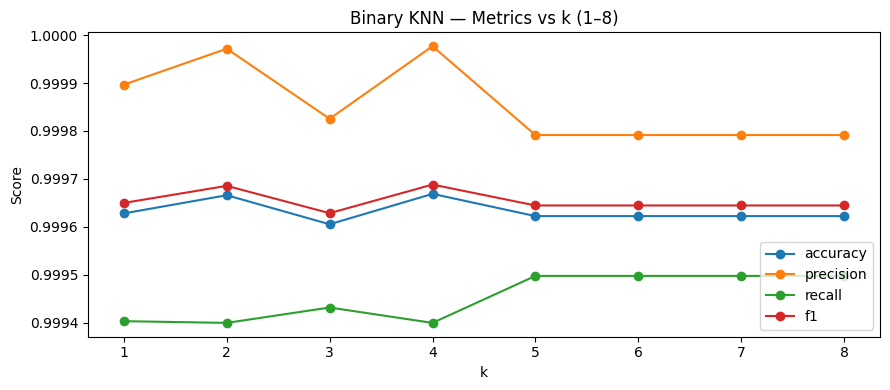


Best k by F1: 4


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

k_values = list(range(1, 9))
binary_results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1, algorithm="auto")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    binary_results.append({
        "k":         k,
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label="ddos"),
        "recall":    recall_score(y_test, y_pred, pos_label="ddos"),
        "f1":        f1_score(y_test, y_pred, pos_label="ddos"),
    })
    print(f"k={k}: accuracy={binary_results[-1]['accuracy']:.4f}  f1={binary_results[-1]['f1']:.4f}")

binary_results_df = pd.DataFrame(binary_results).set_index("k")
display(binary_results_df.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
binary_results_df.plot(ax=ax, marker="o")
ax.set_xlabel("k")
ax.set_ylabel("Score")
ax.set_title("Binary KNN — Metrics vs k (1–8)")
ax.set_xticks(k_values)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_k_bin = int(binary_results_df["f1"].idxmax())
print(f"\nBest k by F1: {best_k_bin}")
knn_model_bin, _ = evaluate_model(
    KNeighborsClassifier(n_neighbors=best_k_bin, n_jobs=-1, algorithm="auto"),
    X_train, X_test, y_train, y_test,
    f"KNN Binary (k={best_k_bin})"
)

### K-Nearest Neighbors (KNN) Multiclass

k=1: accuracy=0.9989  f1(macro)=0.8546
k=2: accuracy=0.9988  f1(macro)=0.8538
k=3: accuracy=0.9991  f1(macro)=0.8565
k=4: accuracy=0.9991  f1(macro)=0.8563
k=5: accuracy=0.9991  f1(macro)=0.8564
k=6: accuracy=0.9991  f1(macro)=0.8560
k=7: accuracy=0.9991  f1(macro)=0.8555
k=8: accuracy=0.9991  f1(macro)=0.8558


,accuracy,precision,recall,f1
k,,,,
1,0.9989,0.8543,0.8549,0.8546
2,0.9988,0.8506,0.8570,0.8538
3,0.9991,0.8580,0.8551,0.8565
4,0.9991,0.8565,0.8562,0.8563
5,0.9991,0.8586,0.8544,0.8564
6,0.9991,0.8565,0.8556,0.8560
7,0.9991,0.8576,0.8537,0.8555
8,0.9991,0.8570,0.8548,0.8558


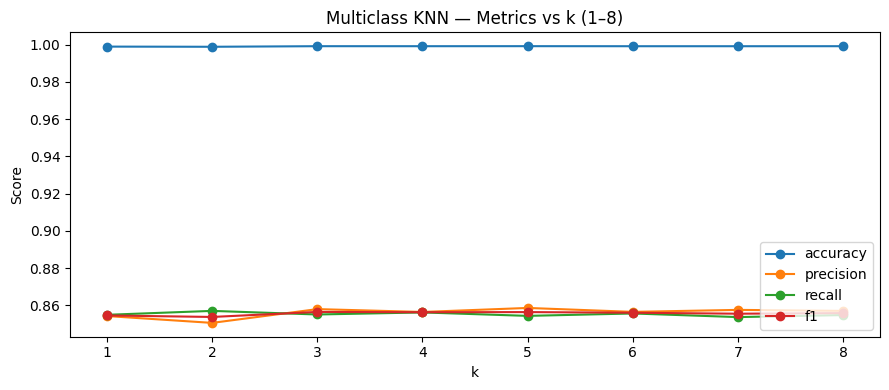


Best k by macro-F1: 3
Train time: 6.0s | Pred time: 2831.952s | Model size: 0.0 KB

Confusion matrix:
[[   433      3      0      0     11      0     10      0]
 [    17   3557      0      0     20    273     16      0]
 [     7      0   1300      0     12      2      5      0]
 [     2      1     27      0     28      0     15      0]
 [     0      2      0      0 150682      0    265      0]
 [     0    151      6      0     15 388139     20      0]
 [     0      2      0      0      0      0 495331     30]
 [     4      0      0      0      0      0      9  16413]]

Classification report:


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        LDAP       0.94      0.95      0.94       457
       MSSQL       0.96      0.92      0.94      3883
     NETBIOS       0.98      0.98      0.98      1326
     Portmap       0.00      0.00      0.00        73
         SYN       1.00      1.00      1.00    150949
         UDP       1.00      1.00      1.00    388331
      benign       1.00      1.00      1.00    495363
slow-attacks       1.00      1.00      1.00     16426

    accuracy                           1.00   1056808
   macro avg       0.86      0.86      0.86   1056808
weighted avg       1.00      1.00      1.00   1056808



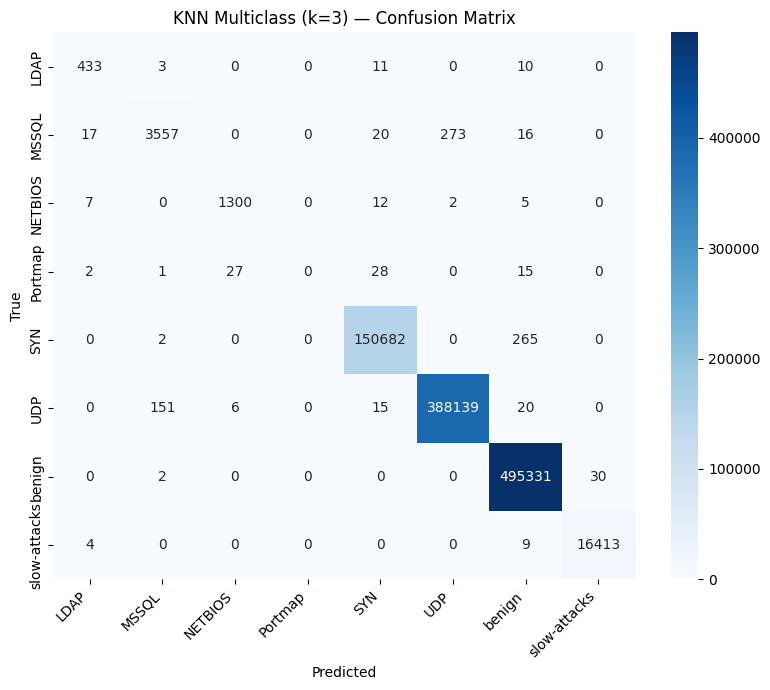

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

k_values = list(range(1, 9))
mc_results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1, algorithm="auto")
    model.fit(X_train_mc, y_train_mc)
    y_pred = model.predict(X_test_mc)
    mc_results.append({
        "k":         k,
        "accuracy":  accuracy_score(y_test_mc, y_pred),
        "precision": precision_score(y_test_mc, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_test_mc, y_pred, average="macro", zero_division=0),
        "f1":        f1_score(y_test_mc, y_pred, average="macro", zero_division=0),
    })
    print(f"k={k}: accuracy={mc_results[-1]['accuracy']:.4f}  f1(macro)={mc_results[-1]['f1']:.4f}")

mc_results_df = pd.DataFrame(mc_results).set_index("k")
display(mc_results_df.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
mc_results_df.plot(ax=ax, marker="o")
ax.set_xlabel("k")
ax.set_ylabel("Score")
ax.set_title("Multiclass KNN — Metrics vs k (1–8)")
ax.set_xticks(k_values)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_k_mc = int(mc_results_df["f1"].idxmax())
print(f"\nBest k by macro-F1: {best_k_mc}")
knn_model_mc, _ = evaluate_model(
    KNeighborsClassifier(n_neighbors=best_k_mc, n_jobs=-1, algorithm="auto"),
    X_train_mc, X_test_mc, y_train_mc, y_test_mc,
    f"KNN Multiclass (k={best_k_mc})"
)

## Extract Models

In [28]:

import os
from pathlib import Path

models_dir = Path("models/knn")
models_dir.mkdir(parents=True, exist_ok=True)
print("Output directory:", models_dir.resolve())
print("Features to be saved:", selected_features)


Output directory: /home/ubuntu/DDoS_ML/training/models/knn
Features to be saved: ['packet_length_max', 'iat_min']


### Save all binary KNN models (k=1–8)

In [29]:

import joblib

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1, algorithm="auto")
    model.fit(X_train, y_train)
    path = models_dir / f"knn_binary_k{k}.joblib"
    joblib.dump(model, path)
    print(f"Saved binary k={k} → {path}")

print("\nAll binary KNN models saved.")


Saved binary k=1 → models/knn/knn_binary_k1.joblib
Saved binary k=2 → models/knn/knn_binary_k2.joblib
Saved binary k=3 → models/knn/knn_binary_k3.joblib
Saved binary k=4 → models/knn/knn_binary_k4.joblib
Saved binary k=5 → models/knn/knn_binary_k5.joblib
Saved binary k=6 → models/knn/knn_binary_k6.joblib
Saved binary k=7 → models/knn/knn_binary_k7.joblib
Saved binary k=8 → models/knn/knn_binary_k8.joblib

All binary KNN models saved.


### Save all multiclass KNN models (k=1–8)

In [30]:

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1, algorithm="auto")
    model.fit(X_train_mc, y_train_mc)
    path = models_dir / f"knn_multi_k{k}.joblib"
    joblib.dump(model, path)
    print(f"Saved multiclass k={k} → {path}")

print("\nAll multiclass KNN models saved.")


Saved multiclass k=1 → models/knn/knn_multi_k1.joblib
Saved multiclass k=2 → models/knn/knn_multi_k2.joblib
Saved multiclass k=3 → models/knn/knn_multi_k3.joblib
Saved multiclass k=4 → models/knn/knn_multi_k4.joblib
Saved multiclass k=5 → models/knn/knn_multi_k5.joblib
Saved multiclass k=6 → models/knn/knn_multi_k6.joblib
Saved multiclass k=7 → models/knn/knn_multi_k7.joblib
Saved multiclass k=8 → models/knn/knn_multi_k8.joblib

All multiclass KNN models saved.


### Save feature-selected train/test splits

In [31]:

import json

# Binary splits (X already scoped to selected_features)
X_train.to_csv(models_dir / "binary_X_train.csv", index=False)
X_test.to_csv(models_dir / "binary_X_test.csv", index=False)
y_train.to_csv(models_dir / "binary_y_train.csv", index=False)
y_test.to_csv(models_dir / "binary_y_test.csv", index=False)

# Multiclass splits
X_train_mc.to_csv(models_dir / "multi_X_train.csv", index=False)
X_test_mc.to_csv(models_dir / "multi_X_test.csv", index=False)
y_train_mc.to_csv(models_dir / "multi_y_train.csv", index=False)
y_test_mc.to_csv(models_dir / "multi_y_test.csv", index=False)

# Persist which features were used so the loader knows column order
with open(models_dir / "features.json", "w") as f:
    json.dump(selected_features, f)

print("Saved train/test splits and feature list to", models_dir.resolve())
print(f"  Binary     — X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"  Multiclass — X_train: {X_train_mc.shape}  X_test: {X_test_mc.shape}")
print(f"  Features: {selected_features}")


Saved train/test splits and feature list to /home/ubuntu/DDoS_ML/training/models/knn
  Binary     — X_train: (4227229, 2)  X_test: (1056808, 2)
  Multiclass — X_train: (4227229, 2)  X_test: (1056808, 2)
  Features: ['packet_length_max', 'iat_min']


## Joblib to C

### Load models for export (binary k=4, multiclass k=3)

In [33]:

import joblib

EXPORT_K_BIN = 4
EXPORT_K_MC  = 3

model_bin_export = joblib.load(models_dir / f"knn_binary_k{EXPORT_K_BIN}.joblib")
model_mc_export  = joblib.load(models_dir / f"knn_multi_k{EXPORT_K_MC}.joblib")

print(f"Loaded binary    k={EXPORT_K_BIN}: {model_bin_export}")
print(f"Loaded multiclass k={EXPORT_K_MC}: {model_mc_export}")


Loaded binary    k=4: KNeighborsClassifier(n_jobs=-1, n_neighbors=4)
Loaded multiclass k=3: KNeighborsClassifier(n_jobs=-1, n_neighbors=3)


#### ONNX

Requires `pip install skl2onnx`. Inputs to the ONNX model must be **float32**. Load in C with the [ONNX Runtime C API](https://onnxruntime.ai/docs/api/c/).

In [35]:

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

n_features = len(selected_features)
initial_type = [("float_input", FloatTensorType([None, n_features]))]

# Binary k=4
onx_bin = convert_sklearn(model_bin_export, initial_types=initial_type)
onnx_bin_path = models_dir / f"knn_binary_k{EXPORT_K_BIN}.onnx"
with open(onnx_bin_path, "wb") as f:
    f.write(onx_bin.SerializeToString())
print(f"ONNX binary     → {onnx_bin_path}  ({onnx_bin_path.stat().st_size / 1e6:.1f} MB)")

# Multiclass k=3
onx_mc = convert_sklearn(model_mc_export, initial_types=initial_type)
onnx_mc_path = models_dir / f"knn_multi_k{EXPORT_K_MC}.onnx"
with open(onnx_mc_path, "wb") as f:
    f.write(onx_mc.SerializeToString())
print(f"ONNX multiclass → {onnx_mc_path}  ({onnx_mc_path.stat().st_size / 1e6:.1f} MB)")


ONNX binary     → models/knn/knn_binary_k4.onnx  (38.0 MB)
ONNX multiclass → models/knn/knn_multi_k3.onnx  (38.0 MB)


#### Binary

Custom flat binary format readable with a single `fread` in C. File layout:

```
[int32] n_samples
[int32] n_features
[int32] k
[int32] n_classes
[float32 × n_samples × n_features]  X_train, row-major
[int32  × n_samples]                 y_train, label-encoded 0…n_classes-1
```

Label decoding is in the companion `*_label_map.json` (int → class string).

In [36]:

import json
import struct
import numpy as np
from sklearn.preprocessing import LabelEncoder

def export_knn_binary(X_tr, y_tr, k, out_path, label_map_path):
    le = LabelEncoder()
    y_enc = le.fit_transform(y_tr).astype(np.int32)
    X_f32 = X_tr.values.astype(np.float32)
    n_samples, n_features = X_f32.shape
    n_classes = len(le.classes_)

    with open(out_path, "wb") as f:
        f.write(struct.pack("iiii", n_samples, n_features, k, n_classes))
        f.write(X_f32.tobytes())
        f.write(y_enc.tobytes())

    label_map = {str(i): cls for i, cls in enumerate(le.classes_)}
    with open(label_map_path, "w") as f:
        json.dump(label_map, f, indent=2)

    size_mb = out_path.stat().st_size / 1e6
    print(f"  n_samples={n_samples}  n_features={n_features}  k={k}  n_classes={n_classes}")
    print(f"  classes: {list(le.classes_)}")
    print(f"  file size: {size_mb:.1f} MB")

bin_path     = models_dir / f"knn_binary_k{EXPORT_K_BIN}.bin"
bin_map_path = models_dir / f"knn_binary_k{EXPORT_K_BIN}_label_map.json"
print(f"Binary export (binary k={EXPORT_K_BIN}):")
export_knn_binary(X_train, y_train, EXPORT_K_BIN, bin_path, bin_map_path)
print(f"  → {bin_path}")

mc_bin_path     = models_dir / f"knn_multi_k{EXPORT_K_MC}.bin"
mc_bin_map_path = models_dir / f"knn_multi_k{EXPORT_K_MC}_label_map.json"
print(f"\nBinary export (multiclass k={EXPORT_K_MC}):")
export_knn_binary(X_train_mc, y_train_mc, EXPORT_K_MC, mc_bin_path, mc_bin_map_path)
print(f"  → {mc_bin_path}")


Binary export (binary k=4):
  n_samples=4227229  n_features=2  k=4  n_classes=2
  classes: ['benign', 'ddos']
  file size: 50.7 MB
  → models/knn/knn_binary_k4.bin

Binary export (multiclass k=3):
  n_samples=4227229  n_features=2  k=3  n_classes=8
  classes: ['LDAP', 'MSSQL', 'NETBIOS', 'Portmap', 'SYN', 'UDP', 'benign', 'slow-attacks']
  file size: 50.7 MB
  → models/knn/knn_multi_k3.bin


#### JSON

All data in one file. **Warning:** ~150–200 MB per file due to 4M+ rows stored as text. Use a streaming JSON parser (e.g. `jsmn`) in C, or prefer the binary format for performance.

In [37]:

import json
from sklearn.preprocessing import LabelEncoder

def export_knn_json(X_tr, y_tr, k, out_path):
    le = LabelEncoder()
    y_enc = le.fit_transform(y_tr).tolist()
    data = {
        "k":          k,
        "features":   selected_features,
        "classes":    le.classes_.tolist(),   # index i → class name
        "n_samples":  len(X_tr),
        "n_features": len(selected_features),
        "X_train":    X_tr.values.tolist(),   # list of [f0, f1, ...]
        "y_train":    y_enc,                  # list of int class indices
    }
    with open(out_path, "w") as f:
        json.dump(data, f)
    size_mb = out_path.stat().st_size / 1e6
    print(f"  classes: {le.classes_.tolist()}")
    print(f"  file size: {size_mb:.1f} MB")
    print(f"  → {out_path}")

json_bin_path = models_dir / f"knn_binary_k{EXPORT_K_BIN}.json"
print(f"JSON export (binary k={EXPORT_K_BIN}):")
export_knn_json(X_train, y_train, EXPORT_K_BIN, json_bin_path)

json_mc_path = models_dir / f"knn_multi_k{EXPORT_K_MC}.json"
print(f"\nJSON export (multiclass k={EXPORT_K_MC}):")
export_knn_json(X_train_mc, y_train_mc, EXPORT_K_MC, json_mc_path)


JSON export (binary k=4):
  classes: ['benign', 'ddos']
  file size: 133.5 MB
  → models/knn/knn_binary_k4.json

JSON export (multiclass k=3):
  classes: ['LDAP', 'MSSQL', 'NETBIOS', 'Portmap', 'SYN', 'UDP', 'benign', 'slow-attacks']
  file size: 133.5 MB
  → models/knn/knn_multi_k3.json


## Testing binary (k=4)

In [42]:
import joblib

model = joblib.load("/home/ubuntu/DDoS_ML/training/models/knn/knn_binary_k4.joblib")

new_data = [[372,9.5367431640625e-07],[74,1.0065059661865234]]

prediction = model.predict(new_data)

print(prediction)

['ddos' 'benign']


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


### KNN Visualization (Binary k=4)

Three plots using the two selected features (`packet_length_max`, `iat_min`):
1. **Prediction points** — training scatter with new samples overlaid
2. **4 nearest neighbors** — the 4 training points that determined each prediction
3. **Decision boundary** — which regions of feature space map to each class

/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Predictions: ['ddos' 'benign']


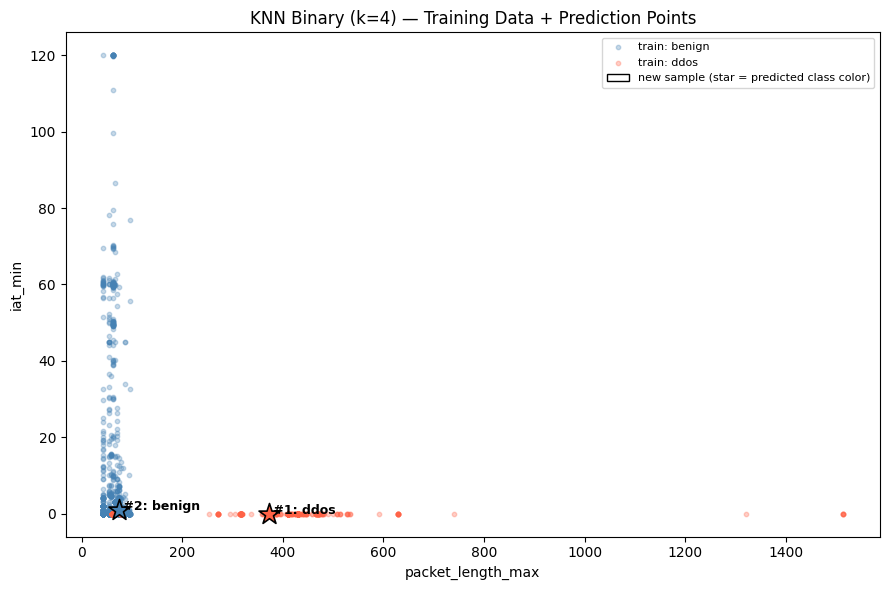

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

feat_x, feat_y = selected_features[0], selected_features[1]

# New samples and their predictions (from the Testing section above)
new_samples = np.array([[372, 9.5367431640625e-07], [74, 1.0065059661865234]])
new_preds   = model.predict(new_samples)
print("Predictions:", new_preds)

# Colors shared across all three plots
colors = {"benign": "steelblue", "ddos": "tomato"}
classes = sorted(y_train.unique())

# --- Plot 1: Training scatter + prediction points ---
SAMPLE_N = 3000
fig, ax = plt.subplots(figsize=(9, 6))

for cls in classes:
    mask = y_train == cls
    idx  = X_train[mask].sample(min(SAMPLE_N, int(mask.sum())), random_state=0).index
    ax.scatter(X_train.loc[idx, feat_x], X_train.loc[idx, feat_y],
               color=colors[cls], alpha=0.3, s=10, label=f"train: {cls}")

# Overlay new samples (star markers, coloured by their predicted class)
for i, (pt, pred) in enumerate(zip(new_samples, new_preds)):
    ax.scatter(pt[0], pt[1], s=250, marker="*", color=colors[pred],
               edgecolors="black", linewidths=1.2, zorder=5)
    ax.annotate(f" #{i+1}: {pred}", (pt[0], pt[1]),
                fontsize=9, fontweight="bold", zorder=6)

star_patch = mpatches.Patch(facecolor="none", edgecolor="black",
                             label="new sample (star = predicted class color)")
handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles=handles + [star_patch], fontsize=8)
ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_title("KNN Binary (k=4) — Training Data + Prediction Points")
plt.tight_layout()
plt.show()

/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


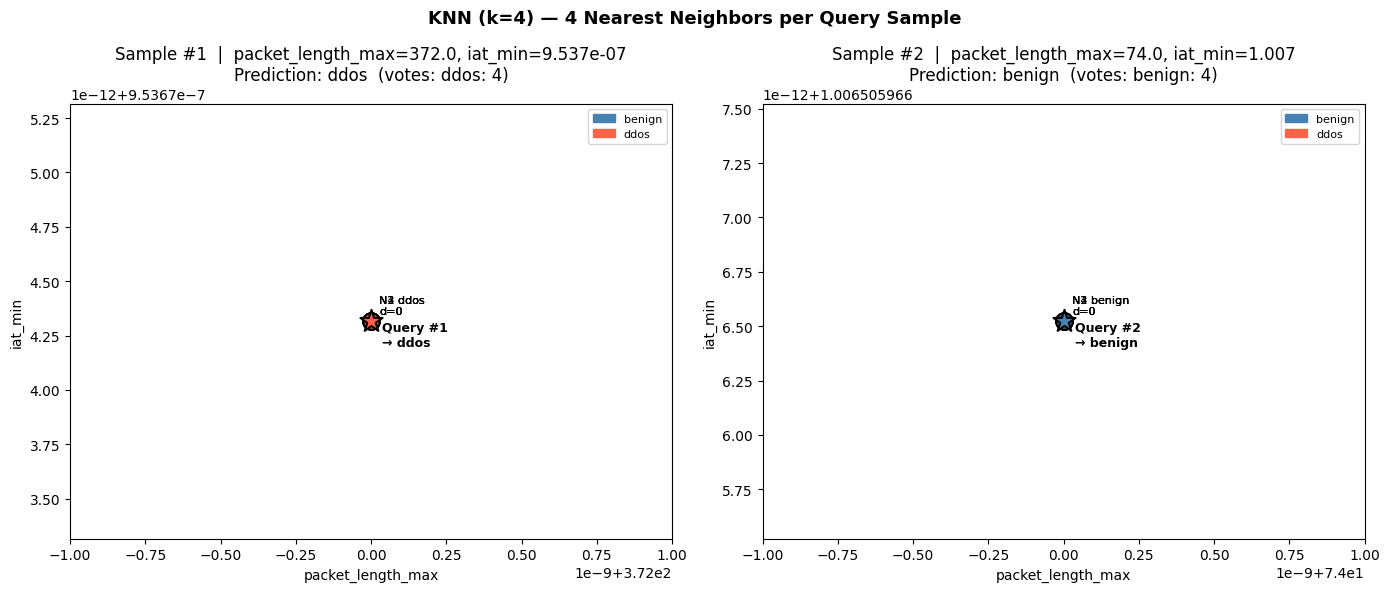

In [46]:
# --- Plot 2: 4 nearest neighbors per new sample ---
# Each subplot zooms in around the query point so the neighbors are visible.

fig, axes = plt.subplots(1, len(new_samples), figsize=(7 * len(new_samples), 6))
if len(new_samples) == 1:
    axes = [axes]

for s_idx, (pt, pred) in enumerate(zip(new_samples, new_preds)):
    ax = axes[s_idx]

    # Retrieve the 4 nearest neighbors from the fitted model
    dists, nbr_indices = model.kneighbors([pt])
    dists       = dists[0]
    nbr_indices = nbr_indices[0]
    nbr_X       = X_train.iloc[nbr_indices]
    nbr_y       = y_train.iloc[nbr_indices]

    # Compute a zoom window: union of query + neighbors, with margin
    all_x = np.append(nbr_X[feat_x].values, pt[0])
    all_y = np.append(nbr_X[feat_y].values, pt[1])
    pad_x = max((all_x.max() - all_x.min()) * 0.4, 1e-9)
    pad_y = max((all_y.max() - all_y.min()) * 0.4, 1e-12)
    win_xl, win_xr = all_x.min() - pad_x, all_x.max() + pad_x
    win_yl, win_yr = all_y.min() - pad_y, all_y.max() + pad_y

    # Background training scatter (within the zoom window only, for speed)
    mask_win = (
        (X_train[feat_x] >= win_xl) & (X_train[feat_x] <= win_xr) &
        (X_train[feat_y] >= win_yl) & (X_train[feat_y] <= win_yr)
    )
    X_win = X_train[mask_win]
    y_win = y_train[mask_win]
    for cls in classes:
        idx = X_win[y_win == cls].index
        ax.scatter(X_win.loc[idx, feat_x], X_win.loc[idx, feat_y],
                   color=colors[cls], alpha=0.25, s=12)

    # Lines and neighbor markers
    for rank, (ni, d, nl) in enumerate(zip(nbr_indices, dists, nbr_y)):
        nx = X_train.iloc[ni][feat_x]
        ny = X_train.iloc[ni][feat_y]
        ax.plot([pt[0], nx], [pt[1], ny], "k--", lw=1.0, zorder=3)
        ax.scatter(nx, ny, s=140, color=colors[nl], edgecolors="black",
                   linewidths=1.5, zorder=4)
        ax.annotate(f"N{rank+1} {nl}\nd={d:.4g}",
                    (nx, ny), textcoords="offset points",
                    xytext=(6, 5), fontsize=8)

    # Query point
    ax.scatter(pt[0], pt[1], s=280, marker="*", color=colors[pred],
               edgecolors="black", linewidths=1.5, zorder=5)
    ax.annotate(f"Query #{s_idx+1}\n→ {pred}",
                (pt[0], pt[1]), textcoords="offset points",
                xytext=(8, -18), fontsize=9, fontweight="bold")

    # Legend
    vote_tally = nbr_y.value_counts().to_dict()
    vote_str   = ", ".join(f"{c}: {v}" for c, v in vote_tally.items())
    ax.set_xlim(win_xl, win_xr)
    ax.set_ylim(win_yl, win_yr)
    ax.set_xlabel(feat_x)
    ax.set_ylabel(feat_y)
    ax.set_title(
        f"Sample #{s_idx+1}  |  {feat_x}={pt[0]}, {feat_y}={pt[1]:.4g}\n"
        f"Prediction: {pred}  (votes: {vote_str})"
    )
    handles = [mpatches.Patch(color=colors[c], label=c) for c in classes]
    ax.legend(handles=handles, fontsize=8)

plt.suptitle("KNN (k=4) — 4 Nearest Neighbors per Query Sample",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


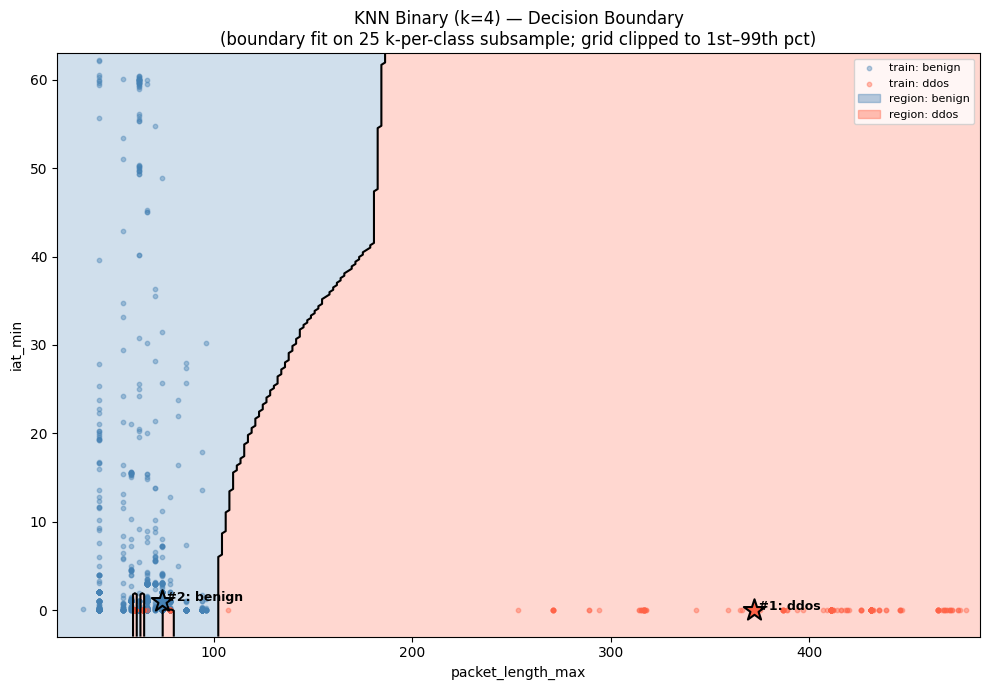

In [47]:
# --- Plot 3: Decision boundary ---
# Building the boundary on 4M training points would be slow, so we fit a
# lightweight KNN (same k=4) on a balanced subsample for grid prediction only.
# The real models/knn/knn_binary_k4.joblib is unchanged.

from sklearn.neighbors import KNeighborsClassifier

VIS_SAMPLE = 25_000  # per class — enough to capture the boundary accurately

vis_parts = []
for cls in classes:
    mask = y_train == cls
    vis_parts.append(X_train[mask].sample(min(VIS_SAMPLE, int(mask.sum())), random_state=42))
X_vis = pd.concat(vis_parts)
y_vis = y_train.loc[X_vis.index]

knn_vis = KNeighborsClassifier(n_neighbors=4, n_jobs=-1)
knn_vis.fit(X_vis, y_vis)

# Grid clipped to 1st–99th percentile so outliers don't distort the view
x_lo = np.percentile(X_train[feat_x], 1);  x_hi = np.percentile(X_train[feat_x], 99)
y_lo = np.percentile(X_train[feat_y], 1);  y_hi = np.percentile(X_train[feat_y], 99)
mx = (x_hi - x_lo) * 0.05;  my = (y_hi - y_lo) * 0.05

xx, yy = np.meshgrid(
    np.linspace(x_lo - mx, x_hi + mx, 250),
    np.linspace(y_lo - my, y_hi + my, 250),
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z_labels = knn_vis.predict(grid)
Z_enc    = np.array([0 if z == "benign" else 1 for z in Z_labels]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))

# Shaded decision regions
ax.contourf(xx, yy, Z_enc, levels=[-0.5, 0.5, 1.5],
            colors=["steelblue", "tomato"], alpha=0.25)
# Decision boundary line
ax.contour(xx, yy, Z_enc, levels=[0.5], colors="black", linewidths=1.5)

# Training scatter (sampled)
SCATTER_N = 2000
for cls in classes:
    mask = y_train == cls
    idx  = X_train[mask].sample(min(SCATTER_N, int(mask.sum())), random_state=1).index
    ax.scatter(X_train.loc[idx, feat_x], X_train.loc[idx, feat_y],
               color=colors[cls], alpha=0.4, s=10, label=f"train: {cls}")

# New query points
for i, (pt, pred) in enumerate(zip(new_samples, new_preds)):
    ax.scatter(pt[0], pt[1], s=260, marker="*", color=colors[pred],
               edgecolors="black", linewidths=1.5, zorder=5)
    ax.annotate(f" #{i+1}: {pred}", (pt[0], pt[1]),
                fontsize=9, fontweight="bold", zorder=6)

ax.set_xlim(x_lo - mx, x_hi + mx)
ax.set_ylim(y_lo - my, y_hi + my)
ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_title(
    "KNN Binary (k=4) — Decision Boundary\n"
    "(boundary fit on 25 k-per-class subsample; grid clipped to 1st–99th pct)"
)

region_handles = [
    mpatches.Patch(color="steelblue", alpha=0.4, label="region: benign"),
    mpatches.Patch(color="tomato",    alpha=0.4, label="region: ddos"),
]
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles + region_handles, fontsize=8)
plt.tight_layout()
plt.show()

## Testing Multiclass (k=3)

In [48]:
import joblib

model_mc = joblib.load("/home/ubuntu/DDoS_ML/training/models/knn/knn_multi_k3.joblib")

new_data = [[372, 9.5367431640625e-07], [74, 1.0065059661865234]]

prediction_mc = model_mc.predict(new_data)

print("Multiclass predictions (k=3):", prediction_mc)

Multiclass predictions (k=3): ['UDP' 'benign']


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


### KNN Visualization (Multiclass k=3)

Same three plots as the binary section, now using `knn_multi_k3` and `X_train_mc` / `y_train_mc`:
1. **Prediction points** — 8-class training scatter with new samples overlaid
2. **3 nearest neighbors** — the 3 training points that determined each prediction
3. **Decision boundary** — one coloured region per class

/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/tmp/ipykernel_2071124/2447003425.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette     = cm.get_cmap("tab10", len(mc_classes))


Multiclass predictions: ['UDP' 'benign']


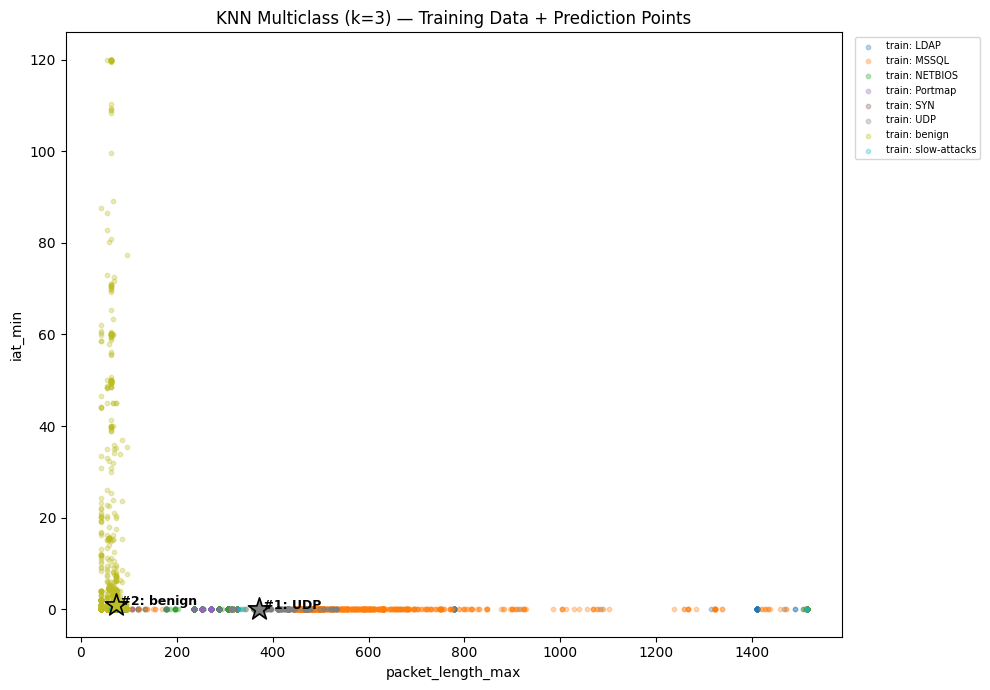

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

feat_x, feat_y = selected_features[0], selected_features[1]

new_samples_mc = np.array([[372, 9.5367431640625e-07], [74, 1.0065059661865234]])
new_preds_mc   = model_mc.predict(new_samples_mc)
print("Multiclass predictions:", new_preds_mc)

# Build a stable color palette for all 8 classes
mc_classes = sorted(y_train_mc.unique())
palette     = cm.get_cmap("tab10", len(mc_classes))
mc_colors   = {cls: palette(i) for i, cls in enumerate(mc_classes)}

# --- Plot 1: Training scatter + prediction points ---
SAMPLE_N = 3000
fig, ax = plt.subplots(figsize=(10, 7))

for cls in mc_classes:
    mask = y_train_mc == cls
    idx  = X_train_mc[mask].sample(min(SAMPLE_N, int(mask.sum())), random_state=0).index
    ax.scatter(X_train_mc.loc[idx, feat_x], X_train_mc.loc[idx, feat_y],
               color=mc_colors[cls], alpha=0.3, s=10, label=f"train: {cls}")

# Overlay new samples as stars coloured by their predicted class
for i, (pt, pred) in enumerate(zip(new_samples_mc, new_preds_mc)):
    ax.scatter(pt[0], pt[1], s=280, marker="*", color=mc_colors[pred],
               edgecolors="black", linewidths=1.2, zorder=5)
    ax.annotate(f" #{i+1}: {pred}", (pt[0], pt[1]),
                fontsize=9, fontweight="bold", zorder=6)

ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_title("KNN Multiclass (k=3) — Training Data + Prediction Points")
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


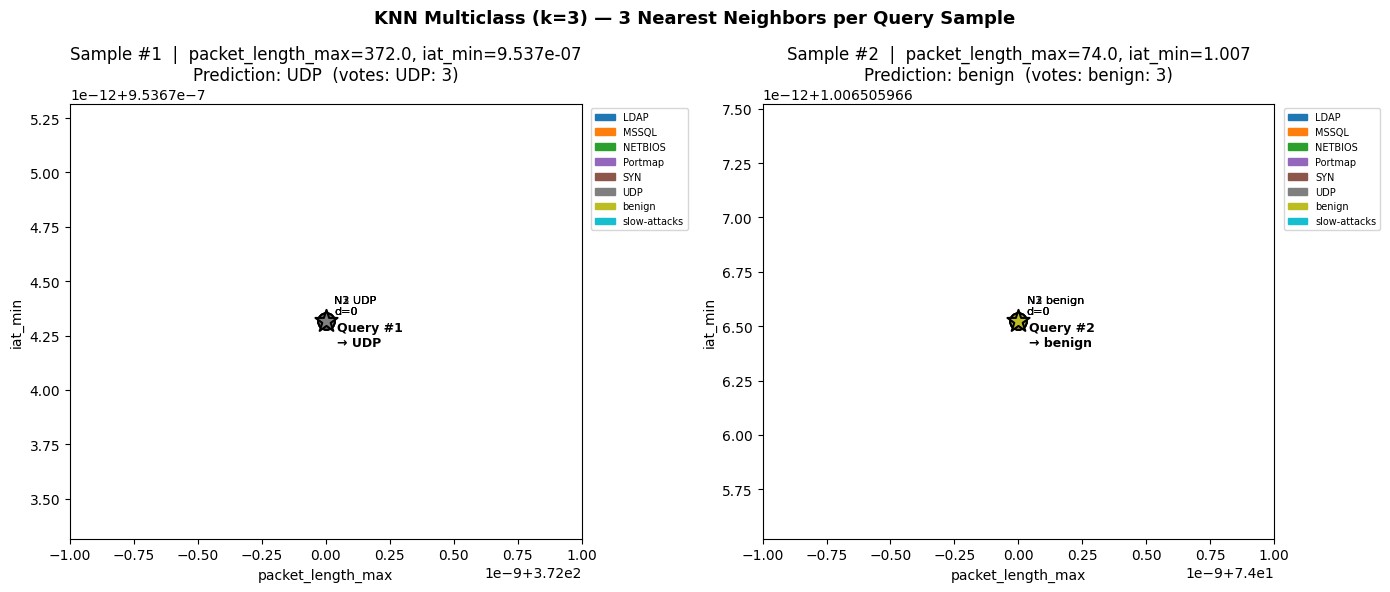

In [50]:
# --- Plot 2: 3 nearest neighbors per new sample (multiclass) ---

fig, axes = plt.subplots(1, len(new_samples_mc), figsize=(7 * len(new_samples_mc), 6))
if len(new_samples_mc) == 1:
    axes = [axes]

for s_idx, (pt, pred) in enumerate(zip(new_samples_mc, new_preds_mc)):
    ax = axes[s_idx]

    dists, nbr_indices = model_mc.kneighbors([pt])
    dists       = dists[0]
    nbr_indices = nbr_indices[0]
    nbr_X       = X_train_mc.iloc[nbr_indices]
    nbr_y       = y_train_mc.iloc[nbr_indices]

    # Zoom window around query + neighbors
    all_x = np.append(nbr_X[feat_x].values, pt[0])
    all_y = np.append(nbr_X[feat_y].values, pt[1])
    pad_x = max((all_x.max() - all_x.min()) * 0.4, 1e-9)
    pad_y = max((all_y.max() - all_y.min()) * 0.4, 1e-12)
    win_xl, win_xr = all_x.min() - pad_x, all_x.max() + pad_x
    win_yl, win_yr = all_y.min() - pad_y, all_y.max() + pad_y

    # Background training scatter clipped to zoom window
    mask_win = (
        (X_train_mc[feat_x] >= win_xl) & (X_train_mc[feat_x] <= win_xr) &
        (X_train_mc[feat_y] >= win_yl) & (X_train_mc[feat_y] <= win_yr)
    )
    X_win = X_train_mc[mask_win]
    y_win = y_train_mc[mask_win]
    for cls in mc_classes:
        idx = X_win[y_win == cls].index
        ax.scatter(X_win.loc[idx, feat_x], X_win.loc[idx, feat_y],
                   color=mc_colors[cls], alpha=0.25, s=12)

    # Neighbor lines + markers
    for rank, (ni, d, nl) in enumerate(zip(nbr_indices, dists, nbr_y)):
        nx = X_train_mc.iloc[ni][feat_x]
        ny = X_train_mc.iloc[ni][feat_y]
        ax.plot([pt[0], nx], [pt[1], ny], "k--", lw=1.0, zorder=3)
        ax.scatter(nx, ny, s=140, color=mc_colors[nl], edgecolors="black",
                   linewidths=1.5, zorder=4)
        ax.annotate(f"N{rank+1} {nl}\nd={d:.4g}",
                    (nx, ny), textcoords="offset points",
                    xytext=(6, 5), fontsize=8)

    # Query point
    ax.scatter(pt[0], pt[1], s=280, marker="*", color=mc_colors[pred],
               edgecolors="black", linewidths=1.5, zorder=5)
    ax.annotate(f"Query #{s_idx+1}\n→ {pred}",
                (pt[0], pt[1]), textcoords="offset points",
                xytext=(8, -18), fontsize=9, fontweight="bold")

    vote_tally = nbr_y.value_counts().to_dict()
    vote_str   = ", ".join(f"{c}: {v}" for c, v in vote_tally.items())
    ax.set_xlim(win_xl, win_xr)
    ax.set_ylim(win_yl, win_yr)
    ax.set_xlabel(feat_x)
    ax.set_ylabel(feat_y)
    ax.set_title(
        f"Sample #{s_idx+1}  |  {feat_x}={pt[0]}, {feat_y}={pt[1]:.4g}\n"
        f"Prediction: {pred}  (votes: {vote_str})"
    )
    handles = [mpatches.Patch(color=mc_colors[c], label=c) for c in mc_classes]
    ax.legend(handles=handles, fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.suptitle("KNN Multiclass (k=3) — 3 Nearest Neighbors per Query Sample",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


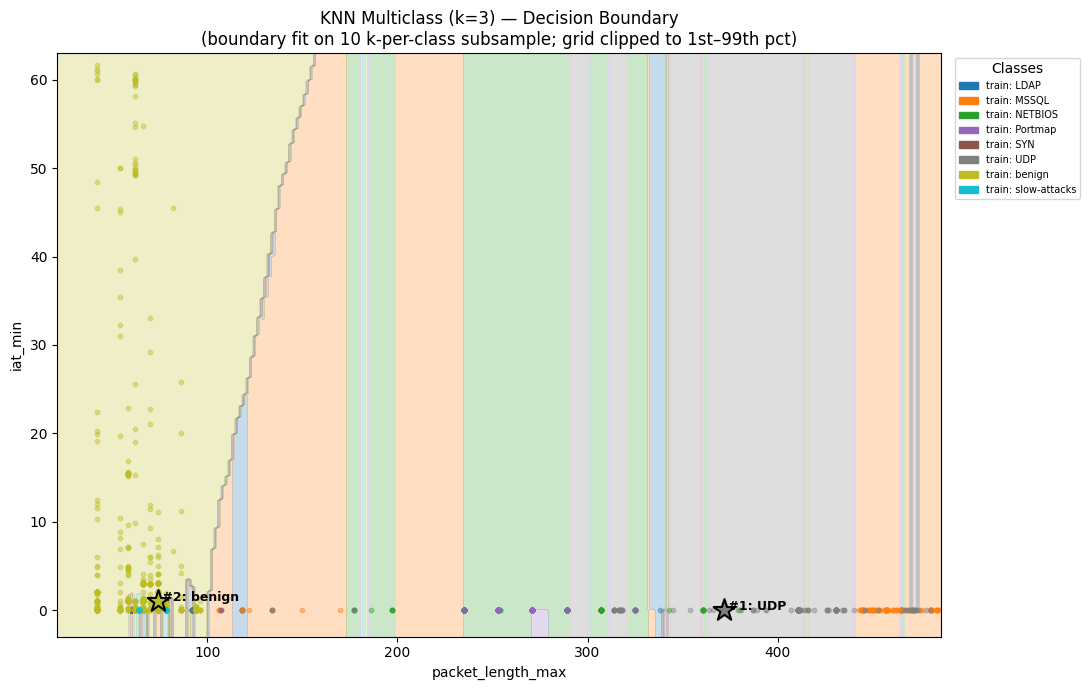

In [51]:
# --- Plot 3: Multiclass decision boundary ---
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import ListedColormap

VIS_SAMPLE = 10_000  # per class

vis_parts_mc = []
for cls in mc_classes:
    mask = y_train_mc == cls
    vis_parts_mc.append(X_train_mc[mask].sample(min(VIS_SAMPLE, int(mask.sum())), random_state=42))
X_vis_mc = pd.concat(vis_parts_mc)
y_vis_mc  = y_train_mc.loc[X_vis_mc.index]

knn_vis_mc = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
knn_vis_mc.fit(X_vis_mc, y_vis_mc)

# Integer-encode classes in the same sorted order as mc_colors
le_mc = LabelEncoder()
le_mc.fit(mc_classes)

# Grid clipped to 1st–99th percentile
x_lo = np.percentile(X_train_mc[feat_x], 1);  x_hi = np.percentile(X_train_mc[feat_x], 99)
y_lo = np.percentile(X_train_mc[feat_y], 1);  y_hi = np.percentile(X_train_mc[feat_y], 99)
mx   = (x_hi - x_lo) * 0.05;  my = (y_hi - y_lo) * 0.05

xx, yy = np.meshgrid(
    np.linspace(x_lo - mx, x_hi + mx, 250),
    np.linspace(y_lo - my, y_hi + my, 250),
)
grid       = np.c_[xx.ravel(), yy.ravel()]
Z_labels   = knn_vis_mc.predict(grid)
Z_enc      = le_mc.transform(Z_labels).reshape(xx.shape)

# Colormap with one entry per class (same order as le_mc.classes_)
region_cmap = ListedColormap([mc_colors[c] for c in le_mc.classes_])

fig, ax = plt.subplots(figsize=(11, 7))

ax.contourf(xx, yy, Z_enc, levels=np.arange(-0.5, len(mc_classes)),
            cmap=region_cmap, alpha=0.25)

# Training scatter
SCATTER_N = 1500
for cls in mc_classes:
    mask = y_train_mc == cls
    idx  = X_train_mc[mask].sample(min(SCATTER_N, int(mask.sum())), random_state=1).index
    ax.scatter(X_train_mc.loc[idx, feat_x], X_train_mc.loc[idx, feat_y],
               color=mc_colors[cls], alpha=0.4, s=10, label=cls)

# New query points
for i, (pt, pred) in enumerate(zip(new_samples_mc, new_preds_mc)):
    ax.scatter(pt[0], pt[1], s=270, marker="*", color=mc_colors[pred],
               edgecolors="black", linewidths=1.5, zorder=5)
    ax.annotate(f" #{i+1}: {pred}", (pt[0], pt[1]),
                fontsize=9, fontweight="bold", zorder=6)

ax.set_xlim(x_lo - mx, x_hi + mx)
ax.set_ylim(y_lo - my, y_hi + my)
ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_title(
    "KNN Multiclass (k=3) — Decision Boundary\n"
    "(boundary fit on 10 k-per-class subsample; grid clipped to 1st–99th pct)"
)

# Legend: training scatter handles + region patches
train_handles = [mpatches.Patch(color=mc_colors[c], label=f"train: {c}") for c in mc_classes]
region_handles = [mpatches.Patch(color=mc_colors[c], alpha=0.3, label=f"region: {c}")
                  for c in mc_classes]
ax.legend(handles=train_handles, fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left",
          title="Classes")
plt.tight_layout()
plt.show()

## Model Reduction

In [55]:
import joblib
import json
import pandas as pd
import numpy as np
import time

model_bc = joblib.load("/home/ubuntu/DDoS_ML/training/models/knn/knn_binary_k4.joblib")

models_dir = "/home/ubuntu/DDoS_ML/training/models/knn"

with open(f"{models_dir}/features.json") as f:
    features = json.load(f)

X_test_csv = pd.read_csv(f"{models_dir}/binary_X_test.csv")
y_test_csv = pd.read_csv(f"{models_dir}/binary_y_test.csv").squeeze()

# Pick one random sample — new sample every run
rng      = np.random.default_rng()
rand_idx = int(rng.integers(len(X_test_csv)))
sample_X = X_test_csv.iloc[[rand_idx]]   # shape (1, n_features) — keeps column names
sample_y = y_test_csv.iloc[rand_idx]

# Predict and time it
t0         = time.perf_counter()
prediction = model_bc.predict(sample_X)
elapsed_ms = (time.perf_counter() - t0) * 1000

# Retrieve the k nearest neighbors (distances + indices)
nbr_dists, nbr_idxs = model_bc.kneighbors(sample_X)
nbr_dists = nbr_dists[0]
nbr_idxs  = nbr_idxs[0]

# Load training labels to show per-neighbor vote breakdown
y_train_csv = pd.read_csv(f"{models_dir}/binary_y_train.csv").squeeze()
nbr_labels  = [y_train_csv.iloc[i] for i in nbr_idxs]
vote_tally  = pd.Series(nbr_labels).value_counts().to_dict()

correct   = prediction[0] == sample_y
n_train   = model_bc.n_samples_fit_
algorithm = model_bc._fit_method

print("=" * 65)
print("  Binary KNN (k=4) — Random Test Sample")
print("=" * 65)
print(f"  Test-set index       : {rand_idx:,}  (of {len(X_test_csv):,} test samples)")
for feat, val in zip(features, sample_X.values[0]):
    print(f"  {feat:<22} : {val:.10g}")
print(f"  True label           : {sample_y}")
print(f"  Predicted label      : {prediction[0]}")
print(f"  Correct              : {'YES ✓' if correct else 'NO ✗'}")
print("-" * 65)
print(f"  Algorithm            : {algorithm}")
print(f"  Training set size    : {n_train:,}  (upper bound for brute-force)")
print(f"  k                    : {model_bc.n_neighbors} neighbors voted")
print(f"  Vote breakdown       : {vote_tally}")
for rank, (d, lbl) in enumerate(zip(nbr_dists, nbr_labels), 1):
    print(f"    N{rank}: dist={d:.6g}  label={lbl}")
print(f"  Prediction time      : {elapsed_ms:.4f} ms")
print("=" * 65)


  Binary KNN (k=4) — Random Test Sample
  Test-set index       : 48,284  (of 1,056,808 test samples)
  packet_length_max      : 74
  iat_min                : 3.695487976e-05
  True label           : benign
  Predicted label      : benign
  Correct              : YES ✓
-----------------------------------------------------------------
  Algorithm            : kd_tree
  Training set size    : 4,227,229  (upper bound for brute-force)
  k                    : 4 neighbors voted
  Vote breakdown       : {'benign': 4}
    N1: dist=0  label=benign
    N2: dist=0  label=benign
    N3: dist=0  label=benign
    N4: dist=0  label=benign
  Prediction time      : 17.4324 ms


In [56]:
import joblib
import json
import pandas as pd
import numpy as np
import time

model_mc = joblib.load("/home/ubuntu/DDoS_ML/training/models/knn/knn_multi_k3.joblib")

models_dir = "/home/ubuntu/DDoS_ML/training/models/knn"

with open(f"{models_dir}/features.json") as f:
    features = json.load(f)

X_test_csv = pd.read_csv(f"{models_dir}/multi_X_test.csv")
y_test_csv = pd.read_csv(f"{models_dir}/multi_y_test.csv").squeeze()

# Pick one random sample — new sample every run
rng      = np.random.default_rng()
rand_idx = int(rng.integers(len(X_test_csv)))
sample_X = X_test_csv.iloc[[rand_idx]]
sample_y = y_test_csv.iloc[rand_idx]

# Predict and time it
t0            = time.perf_counter()
prediction_mc = model_mc.predict(sample_X)
elapsed_ms    = (time.perf_counter() - t0) * 1000

# Retrieve the k nearest neighbors
nbr_dists, nbr_idxs = model_mc.kneighbors(sample_X)
nbr_dists = nbr_dists[0]
nbr_idxs  = nbr_idxs[0]

# Load training labels for vote breakdown
y_train_csv = pd.read_csv(f"{models_dir}/multi_y_train.csv").squeeze()
nbr_labels  = [y_train_csv.iloc[i] for i in nbr_idxs]
vote_tally  = pd.Series(nbr_labels).value_counts().to_dict()

correct   = prediction_mc[0] == sample_y
n_train   = model_mc.n_samples_fit_
algorithm = model_mc._fit_method

print("=" * 65)
print("  Multiclass KNN (k=3) — Random Test Sample")
print("=" * 65)
print(f"  Test-set index       : {rand_idx:,}  (of {len(X_test_csv):,} test samples)")
for feat, val in zip(features, sample_X.values[0]):
    print(f"  {feat:<22} : {val:.10g}")
print(f"  True label           : {sample_y}")
print(f"  Predicted label      : {prediction_mc[0]}")
print(f"  Correct              : {'YES ✓' if correct else 'NO ✗'}")
print("-" * 65)
print(f"  Algorithm            : {algorithm}")
print(f"  Training set size    : {n_train:,}  (upper bound for brute-force)")
print(f"  k                    : {model_mc.n_neighbors} neighbors voted")
print(f"  Vote breakdown       : {vote_tally}")
for rank, (d, lbl) in enumerate(zip(nbr_dists, nbr_labels), 1):
    print(f"    N{rank}: dist={d:.6g}  label={lbl}")
print(f"  Prediction time      : {elapsed_ms:.4f} ms")
print("=" * 65)


  Multiclass KNN (k=3) — Random Test Sample
  Test-set index       : 616,634  (of 1,056,808 test samples)
  packet_length_max      : 62
  iat_min                : 119.934525
  True label           : benign
  Predicted label      : benign
  Correct              : YES ✓
-----------------------------------------------------------------
  Algorithm            : kd_tree
  Training set size    : 4,227,229  (upper bound for brute-force)
  k                    : 3 neighbors voted
  Vote breakdown       : {'benign': 3}
    N1: dist=4.3869e-05  label=benign
    N2: dist=0.00011301  label=benign
    N3: dist=0.000137091  label=benign
  Prediction time      : 16.9841 ms


/tmp/ipykernel_2071124/2636883300.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = cm.get_cmap("tab10", len(mc_classes))


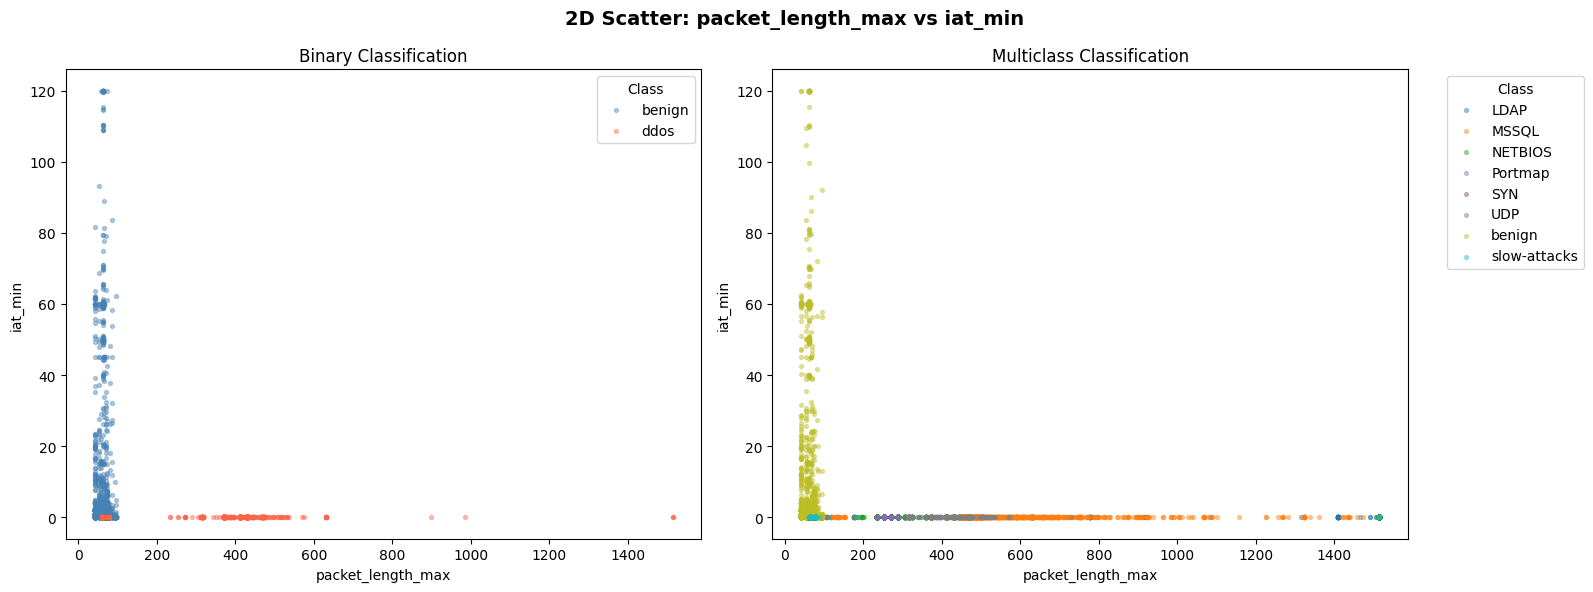

In [57]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

if len(selected_features) < 2:
    raise ValueError("Need at least 2 selected features for a 2D scatter plot.")

feat_x, feat_y = selected_features[0], selected_features[1]
sample_n = 5000  # points per class to keep the plot fast

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Binary scatter ---
ax = axes[0]
df_vis_bin = pd.concat([X_train, X_test])
y_vis_bin  = pd.concat([y_train, y_test])

colors_bin = {"benign": "steelblue", "ddos": "tomato"}
for cls in sorted(y_vis_bin.unique()):
    mask = y_vis_bin == cls
    idx  = df_vis_bin[mask].sample(min(sample_n, int(mask.sum())), random_state=0).index
    ax.scatter(df_vis_bin.loc[idx, feat_x], df_vis_bin.loc[idx, feat_y],
               label=cls, alpha=0.4, s=8, color=colors_bin.get(cls, "gray"))
ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_title("Binary Classification")
ax.legend(title="Class")

# --- Multiclass scatter ---
ax = axes[1]
df_vis_mc = pd.concat([X_train_mc, X_test_mc])
y_vis_mc  = pd.concat([y_train_mc, y_test_mc])

mc_classes = sorted(y_vis_mc.unique())
palette = cm.get_cmap("tab10", len(mc_classes))
for i, cls in enumerate(mc_classes):
    mask = y_vis_mc == cls
    idx  = df_vis_mc[mask].sample(min(sample_n, int(mask.sum())), random_state=0).index
    ax.scatter(df_vis_mc.loc[idx, feat_x], df_vis_mc.loc[idx, feat_y],
               label=cls, alpha=0.4, s=8, color=palette(i))
ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_title("Multiclass Classification")
ax.legend(title="Class", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.suptitle(f"2D Scatter: {feat_x} vs {feat_y}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()